### Simulación y Diagnóstico OLS
- La diferencia entre el parámetro poblacional y el estimador muestral, cómo se comporta la función de costo y cómo validar los supuestos críticos de Gauss-Markov mediante gráficos de diagnóstico.

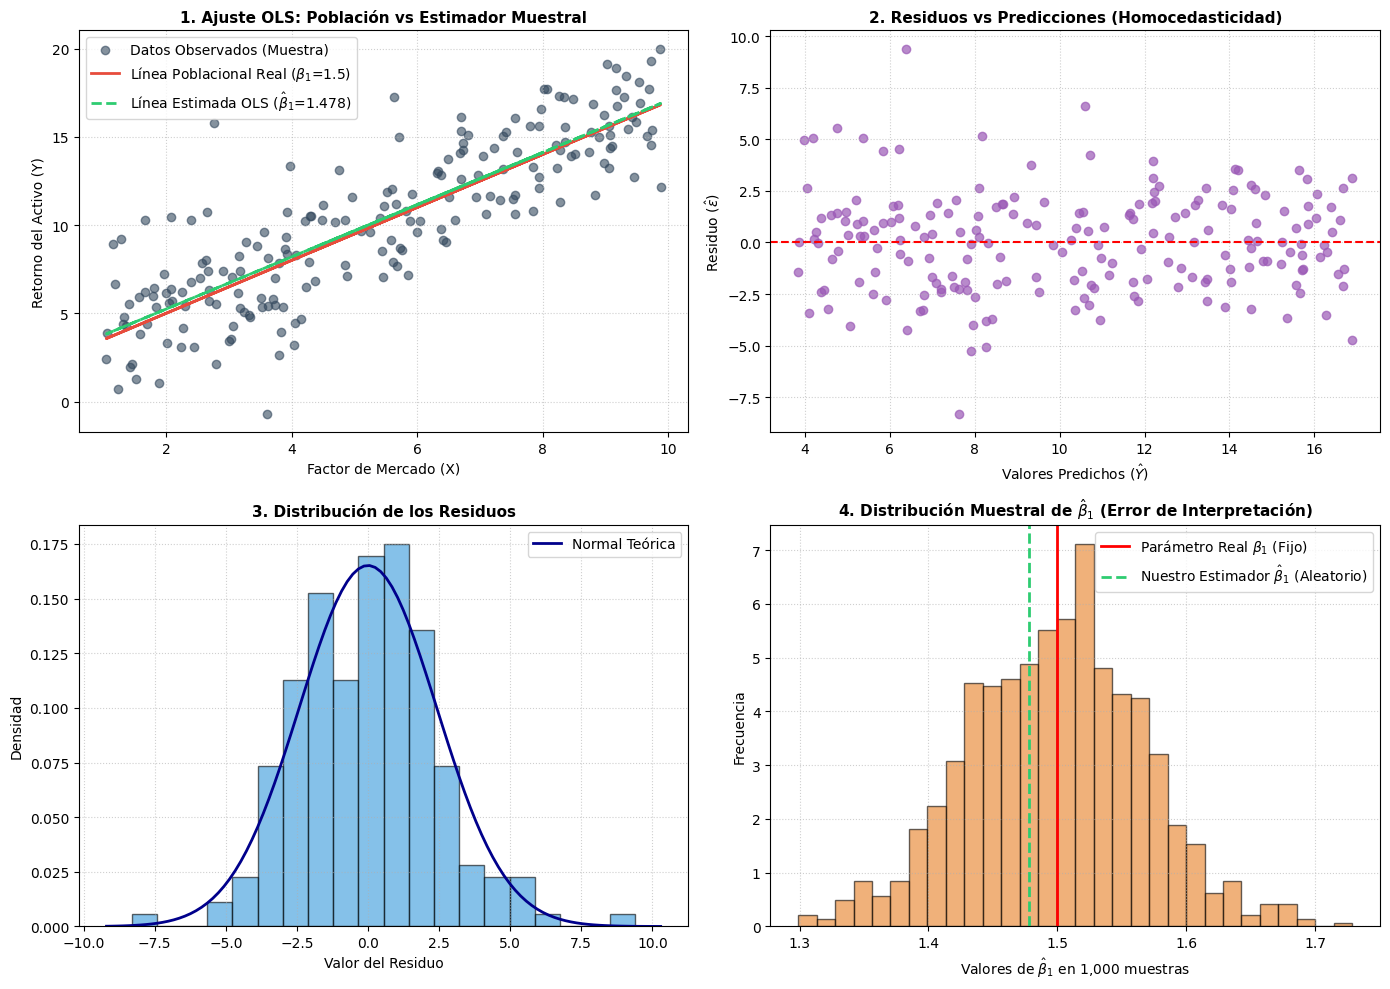

=================== REPORTE ACADÉMICO FRM PART 1 ===================
Cálculo Manual por Momentos (Cov/Var): Pendiente = 1.4783
Estimador OLS de la Pendiente (beta_1_hat): 1.4783
Error Estándar del Estimador (SE):          0.0649
Estadístico t (H0: beta_1 = 0):            22.7951
P-Valor:                                    2.8755e-57
R-cuadrado del modelo:                      0.7241


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats

# Definir una semilla para la replicabilidad del experimento (FRM Quantitative Section)
np.random.seed(42)

# =============================================================================
# 1. EL MODELO POBLACIONAL REAL (Oculto en el mercado real)
# Y = beta_0 + beta_1 * X + epsilon
# =============================================================================
N = 200
BETA_0_TRUE = 2.0   # Intercepto poblacional (Retorno base del activo cuando el mercado no se mueve)
BETA_1_TRUE = 1.5   # Pendiente poblacional (Beta real del activo / Sensibilidad frente al mercado)

# Supuesto: X tiene variación (Var(X) > 0). No hay colinealidad perfecta.
X = np.random.uniform(1, 10, N)

# Supuesto: Homocedasticidad (Varianza constante) y Exogeneidad E[epsilon|X] = 0
sigma_error = 2.5
epsilon = np.random.normal(0, sigma_error, N)

# Generación de la variable dependiente Y
Y = BETA_0_TRUE + BETA_1_TRUE * X + epsilon

# =============================================================================
# 2. ESTIMACIÓN MECÁNICA POR MÍNIMOS CUADRADOS ORDINARIOS (OLS)
# =============================================================================
# Cálculo manual basado en momentos bivariados para contrastar con OLS
cov_xy = np.cov(X, Y)[0, 1]
var_x = np.var(X, ddof=1)
beta_1_manual = cov_xy / var_x
beta_0_manual = np.mean(Y) - beta_1_manual * np.mean(X)

# Estimación formal usando Statsmodels (Función de costo que minimiza RSS)
X_with_constant = sm.add_constant(X) # Agrega el vector de 1s para estimar beta_0
model = sm.OLS(Y, X_with_constant)
results = model.fit()

# Extraer estimadores muestrales y sus errores estándar
beta_0_hat = results.params[0]
beta_1_hat = results.params[1]
se_beta_1 = results.bse[1]
t_stat_beta_1 = results.tvalues[1]
p_val_beta_1 = results.pvalues[1]

# =============================================================================
# 3. VISUALIZACIÓN Y DIAGNÓSTICO DE SUPUESTOS
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- GRÁFICO 1: Línea de Mejor Ajuste y Error de Interpretación ---
axes[0, 0].scatter(X, Y, color='#34495e', alpha=0.6, label='Datos Observados (Muestra)')
axes[0, 0].plot(X, BETA_0_TRUE + BETA_1_TRUE * X, color='#e74c3c', linewidth=2, label=f'Línea Poblacional Real ($\\beta_1$={BETA_1_TRUE})')
axes[0, 0].plot(X, results.fittedvalues, color='#2ecc71', linewidth=2, linestyle='--', label=f'Línea Estimada OLS ($\\hat{{\\beta}}_1$={beta_1_hat:.3f})')
axes[0, 0].set_title('1. Ajuste OLS: Población vs Estimador Muestral', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Factor de Mercado (X)')
axes[0, 0].set_ylabel('Retorno del Activo (Y)')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# --- GRÁFICO 2: Análisis de Residuos vs X (Verificación de Homocedasticidad) ---
residuos = results.resid
axes[0, 1].scatter(results.fittedvalues, residuos, color='#9b59b6', alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('2. Residuos vs Predicciones (Homocedasticidad)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Valores Predichos ($\\hat{Y}$)')
axes[0, 1].set_ylabel('Residuo ($\\hat{\\epsilon}$)')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# --- GRÁFICO 3: Distribución de los Errores (Prueba de Inferencia Estadística) ---
axes[1, 0].hist(residuos, bins=20, density=True, color='#3498db', alpha=0.6, edgecolor='black')
# Superponer curva normal teórica
xmin, xmax = axes[1, 0].get_xlim()
x_axis = np.linspace(xmin, xmax, 100)
axes[1, 0].plot(x_axis, stats.norm.pdf(x_axis, 0, np.std(residuos)), color='darkblue', linewidth=2, label='Normal Teórica')
axes[1, 0].set_title('3. Distribución de los Residuos', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Valor del Residuo')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# --- GRÁFICO 4: El Error del Estudiante (Distribución Muestral del Estimador) ---
# Simulamos 1000 muestras diferentes para demostrar que beta_hat es una VARIABLE ALEATORIA
beta_1_simulados = []
for _ in range(1000):
    eps_sim = np.random.normal(0, sigma_error, N)
    Y_sim = BETA_0_TRUE + BETA_1_TRUE * X + eps_sim
    model_sim = sm.OLS(Y_sim, X_with_constant).fit()
    beta_1_simulados.append(model_sim.params[1])

axes[1, 1].hist(beta_1_simulados, bins=30, color='#e67e22', alpha=0.6, edgecolor='black', density=True)
axes[1, 1].axvline(BETA_1_TRUE, color='red', linewidth=2, label=r'Parámetro Real $\beta_1$ (Fijo)')
axes[1, 1].axvline(beta_1_hat, color='#2ecc71', linewidth=2, linestyle='--', label=r'Nuestro Estimador $\hat{\beta}_1$ (Aleatorio)')
axes[1, 1].set_title(r'4. Distribución Muestral de $\hat{\beta}_1$ (Error de Interpretación)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel(r'Valores de $\hat{\beta}_1$ en 1,000 muestras')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. REPORTE CUANTITATIVO DE REPASO (Métricas Clave de Examen)
# =============================================================================
print("=================== REPORTE ACADÉMICO FRM PART 1 ===================")
print(f"Cálculo Manual por Momentos (Cov/Var): Pendiente = {beta_1_manual:.4f}")
print(f"Estimador OLS de la Pendiente (beta_1_hat): {beta_1_hat:.4f}")
print(f"Error Estándar del Estimador (SE):          {se_beta_1:.4f}")
print(f"Estadístico t (H0: beta_1 = 0):            {t_stat_beta_1:.4f}")
print(f"P-Valor:                                    {p_val_beta_1:.4e}")
print(f"R-cuadrado del modelo:                      {results.rsquared:.4f}")
print("====================================================================")


In [2]:
from statsmodels.stats.stattools import jarque_bera

# Aplicar la prueba de Jarque-Bera sobre los residuos calculados previamente
jb_score, p_value, skew, kurtosis = jarque_bera(residuos)

print("--- PRUEBA DE NORMALIDAD DE JARQUE-BERA ---")
print(f"Estadístico JB: {jb_score:.4f}")
print(f"P-Valor:         {p_value:.4f}")
print(f"Asimetría (Skewness) de los residuos: {skew:.4f}  (Objetivo Normal = 0)")
print(f"Curtosis de los residuos:            {kurtosis:.4f}  (Objetivo Normal = 3)")

if p_value < 0.05:
    print("\nResultado: RECHAZAMOS H0. Los residuos NO siguen una distribución normal.")
else:
    print("\nResultado: NO RECHAZAMOS H0. Confirmado, los residuos SI se distribuyen normalmente.")


--- PRUEBA DE NORMALIDAD DE JARQUE-BERA ---
Estadístico JB: 9.1994
P-Valor:         0.0101
Asimetría (Skewness) de los residuos: 0.2312  (Objetivo Normal = 0)
Curtosis de los residuos:            3.9434  (Objetivo Normal = 3)

Resultado: RECHAZAMOS H0. Los residuos NO siguen una distribución normal.


In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.stattools import jarque_bera

# 1. GENERACIÓN DE DATOS CON ERRORES INTENCIONALMENTE NO NORMALES
np.random.seed(42)
N = 200
X = np.random.uniform(1, 10, N)

# Generamos errores usando una distribución 't de Student' con solo 3 grados de libertad.
# Esto asegura colas extremadamente pesadas y picos que violan la normalidad (Falla JB).
epsilon_no_normal = np.random.standard_t(df=3, size=N) * 1.5

BETA_0_TRUE = 2.0
BETA_1_TRUE = 1.5  # Existe un efecto real en la población

Y = BETA_0_TRUE + BETA_1_TRUE * X + epsilon_no_normal

# 2. AJUSTE DEL MODELO OLS
X_with_constant = sm.add_constant(X)
model = sm.OLS(Y, X_with_constant)
results = model.fit()

# 3. VERIFICACIÓN DE JARQUE-BERA
jb_score, p_value_jb, skew, kurtosis = jarque_bera(results.resid)

# 4. EXTRACCIÓN Y CÁLCULO MANUAL DEL ESTADÍSTICO T PARA LA PENDIENTE (beta_1)
beta_1_hat = results.params[1]     # Nuestro coeficiente estimado
se_beta_1 = results.bse[1]         # Error estándar del coeficiente (usa la varianza de los residuos)

# El estadístico t bajo H0: beta_1 = 0 se calcula: (estimador - valor_H0) / SE
t_estadistico_manual = (beta_1_hat - 0) / se_beta_1
p_valor_t = results.pvalues[1]     # P-valor de dos colas para la prueba t

# Valor crítico de una distribución t para el 95% de confianza (Alpha = 0.05) con N-2 grados de libertad
grados_libertad = N - 2
valor_critico = stats.t.ppf(1 - 0.05/2, df=grados_libertad)

# 5. REPORTE EJECUTIVO DE RESULTADOS
print("=================== RESULTADOS DE CONTRASTE DE HIPÓTESIS ===================")
print(f"1. PRUEBA DE NORMALIDAD (Jarque-Bera):")
print(f"   - P-Valor de JB: {p_value_jb:.4e}")
print(f"   - Conclusión JB: Rechazamos H0 (Los residuos NO son normales de forma contundente)")
print(f"   - Curtosis observada: {kurtosis:.4f} (Muy superior al 3.0 de una normal)")

print(f"\n2. PRUEBA DE INFERENCIA (Invocando TLC por muestra N={N}):")
print(f"   - Coeficiente estimado (beta_1_hat): {beta_1_hat:.4f}")
print(f"   - Error Estándar (SE):              {se_beta_1:.4f}")
print(f"   - Estadístico t calculado:           {t_estadistico_manual:.4f}")
print(f"   - Valor Crítico de la tabla t (95%): ±{valor_critico:.4f}")
print(f"   - P-Valor de la prueba t:           {p_valor_t:.4e}")

print("\n3. DECISIÓN FINAL SOBRE LA COBERTURA / EFECTO:")
if abs(t_estadistico_manual) > valor_critico:
    print("   -> RECHAZAMOS H0. A pesar de la no-normalidad de los residuos,")
    print("      el TLC nos garantiza que el estadístico t es válido.")
    print("      Concluimos que X tiene un efecto lineal estadísticamente significativo sobre Y.")
else:
    print("   -> NO RECHAZAMOS H0. No hay suficiente evidencia para afirmar un efecto lineal.")
print("============================================================================")


=================== RESULTADOS DE CONTRASTE DE HIPÓTESIS ===================
1. PRUEBA DE NORMALIDAD (Jarque-Bera):
   - P-Valor de JB: 1.6343e-10
   - Conclusión JB: Rechazamos H0 (Los residuos NO son normales de forma contundente)
   - Curtosis observada: 5.3016 (Muy superior al 3.0 de una normal)

2. PRUEBA DE INFERENCIA (Invocando TLC por muestra N=200):
   - Coeficiente estimado (beta_1_hat): 1.4766
   - Error Estándar (SE):              0.0563
   - Estadístico t calculado:           26.2166
   - Valor Crítico de la tabla t (95%): ±1.9720
   - P-Valor de la prueba t:           2.5994e-66

3. DECISIÓN FINAL SOBRE LA COBERTURA / EFECTO:
   -> RECHAZAMOS H0. A pesar de la no-normalidad de los residuos,
      el TLC nos garantiza que el estadístico t es válido.
      Concluimos que X tiene un efecto lineal estadísticamente significativo sobre Y.


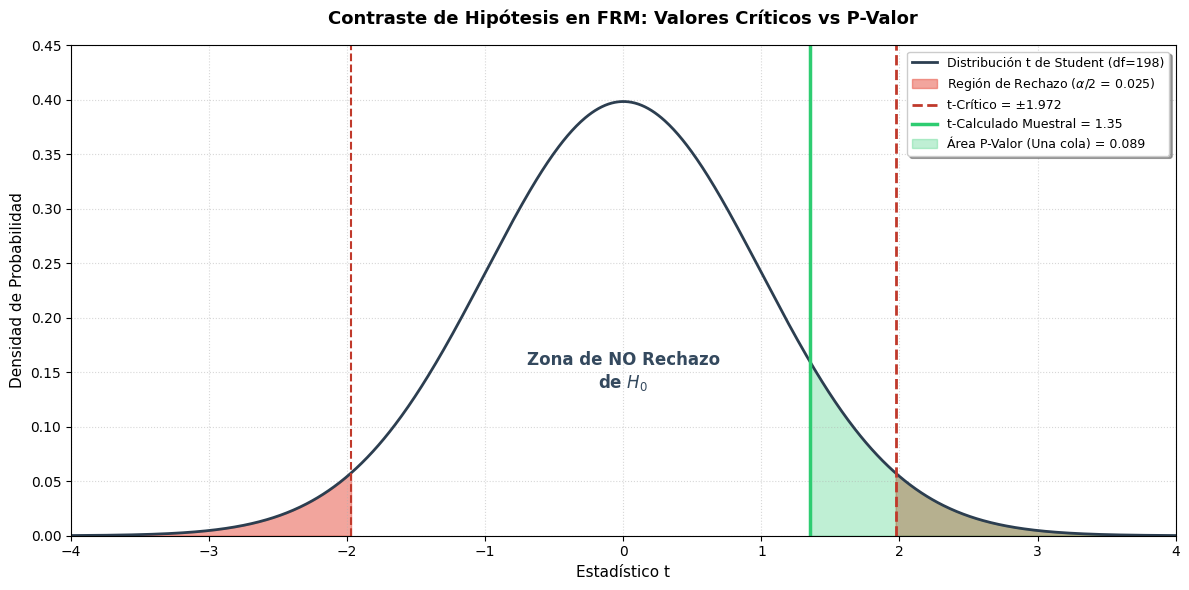

=================== REPORTE DE DECISIÓN ESTADÍSTICA ===================
Nivel de Significancia (alpha):  0.05  (Confianza = 0.95)
Estadístico t Crítico:          ±1.9720
Estadístico t Calculado:         1.3500
P-Valor de la Prueba:            0.1786
-----------------------------------------------------------------------
VEREDICTO POR ENFOQUE DE VALOR CRÍTICO:
¿|t-Calculado| > t-Crítico? -> ¿1.35 > 1.97? -> False

VEREDICTO POR ENFOQUE DE P-VALOR:
¿P-Valor < alpha?          -> ¿0.1786 < 0.05? -> False
-----------------------------------------------------------------------
CONCLUSIÓN FINAL: Ambos enfoques coinciden matemáticamente.
-> NO RECHAZAMOS H0. El coeficiente no es estadísticamente diferente de cero.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# --- 1. CONFIGURACIÓN DEL EXPERIMENTO (Bajo H0: beta_1 = 0) ---
np.random.seed(15)
N = 200
grados_libertad = N - 2
alpha = 0.05  # Nivel de significancia (5%)

# Simulamos un Estadístico t muestral cualquiera para ver dónde cae en la gráfica
# Supongamos que en nuestro modelo OLS obtuvimos un t_calculado de 1.35
t_calculado = 1.35 

# --- 2. CÁLCULO DE VALORES CRÍTICOS Y P-VALOR ---
# Valor crítico bilateral (dos colas) para un alpha de 0.05
t_critico = stats.t.ppf(1 - alpha/2, df=grados_libertad)

# P-Valor: es el área acumulada en las colas más allá de nuestro t_calculado
p_valor = 2 * (1 - stats.t.cdf(abs(t_calculado), df=grados_libertad))

# --- 3. GENERACIÓN DEL GRÁFICO DE DISTRIBUCIÓN ---
plt.figure(figsize=(12, 6))

# Crear el eje X para la campana de la distribución t
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=grados_libertad)
plt.plot(x, y, color='#2c3e50', linewidth=2, label=f'Distribución t de Student (df={grados_libertad})')

# --- ENFOQUE 1: Regiones de Rechazo (Zonas Rojas) ---
# Cola Izquierda
x_izq = np.linspace(-4, -t_critico, 100)
plt.fill_between(x_izq, stats.t.pdf(x_izq, df=grados_libertad), color='#e74c3c', alpha=0.5, 
                 label=f'Región de Rechazo ($\\alpha/2$ = {alpha/2:.3f})')
# Cola Derecha
x_der = np.linspace(t_critico, 4, 100)
plt.fill_between(x_der, stats.t.pdf(x_der, df=grados_libertad), color='#e74c3c', alpha=0.5)

# Dibujar líneas de los Valores Críticos
plt.axvline(t_critico, color='#c0392b', linestyle='--', linewidth=2, label=f't-Crítico = ±{t_critico:.3f}')
plt.axvline(-t_critico, color='#c0392b', linestyle='--')

# --- ENFOQUE 2: Nuestro Estadístico Calculado e Ilustración del P-Valor ---
plt.axvline(t_calculado, color='#2ecc71', linestyle='-', linewidth=2.5, label=f't-Calculado Muestral = {t_calculado:.2f}')

# Sombrear el área del P-Valor (Área bajo la curva desde t_calculado hacia la derecha)
x_p_val = np.linspace(abs(t_calculado), 4, 100)
plt.fill_between(x_p_val, stats.t.pdf(x_p_val, df=grados_libertad), color='#2ecc71', alpha=0.3, 
                 label=f'Área P-Valor (Una cola) = {p_valor/2:.3f}')

# --- DETALLES DE LA GRÁFICA ---
plt.title('Contraste de Hipótesis en FRM: Valores Críticos vs P-Valor', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Estadístico t', fontsize=11)
plt.ylabel('Densidad de Probabilidad', fontsize=11)
plt.xlim(-4, 4)
plt.ylim(0, 0.45)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', fontsize=9, frameon=True, shadow=True)

# Anotaciones explicativas en la gráfica
plt.text(0, 0.15, 'Zona de NO Rechazo\nde $H_0$', ha='center', va='center', fontsize=12, fontweight='bold', color='#34495e')

plt.tight_layout()
plt.show()

# --- 4. REPORTE DE DECISIÓN LOGICIAL ---
print("=================== REPORTE DE DECISIÓN ESTADÍSTICA ===================")
print(f"Nivel de Significancia (alpha):  {alpha:.2f}  (Confianza = {1-alpha:.2f})")
print(f"Estadístico t Crítico:          ±{t_critico:.4f}")
print(f"Estadístico t Calculado:         {t_calculado:.4f}")
print(f"P-Valor de la Prueba:            {p_valor:.4f}")
print("-----------------------------------------------------------------------")

print("VEREDICTO POR ENFOQUE DE VALOR CRÍTICO:")
condicion_t = abs(t_calculado) > t_critico
print(f"¿|t-Calculado| > t-Crítico? -> ¿{abs(t_calculado):.2f} > {t_critico:.2f}? -> {condicion_t}")

print("\nVEREDICTO POR ENFOQUE DE P-VALOR:")
condicion_p = p_valor < alpha
print(f"¿P-Valor < alpha?          -> ¿{p_valor:.4f} < {alpha:.2f}? -> {condicion_p}")

print("-----------------------------------------------------------------------")
if not condicion_t and not condicion_p:
    print("CONCLUSIÓN FINAL: Ambos enfoques coinciden matemáticamente.")
    print("-> NO RECHAZAMOS H0. El coeficiente no es estadísticamente diferente de cero.")
else:
    print("CONCLUSIÓN FINAL: Ambos enfoques coinciden matemáticamente.")
    print("-> RECHAZAMOS H0. El coeficiente es estadísticamente significativo.")
print("=======================================================================")


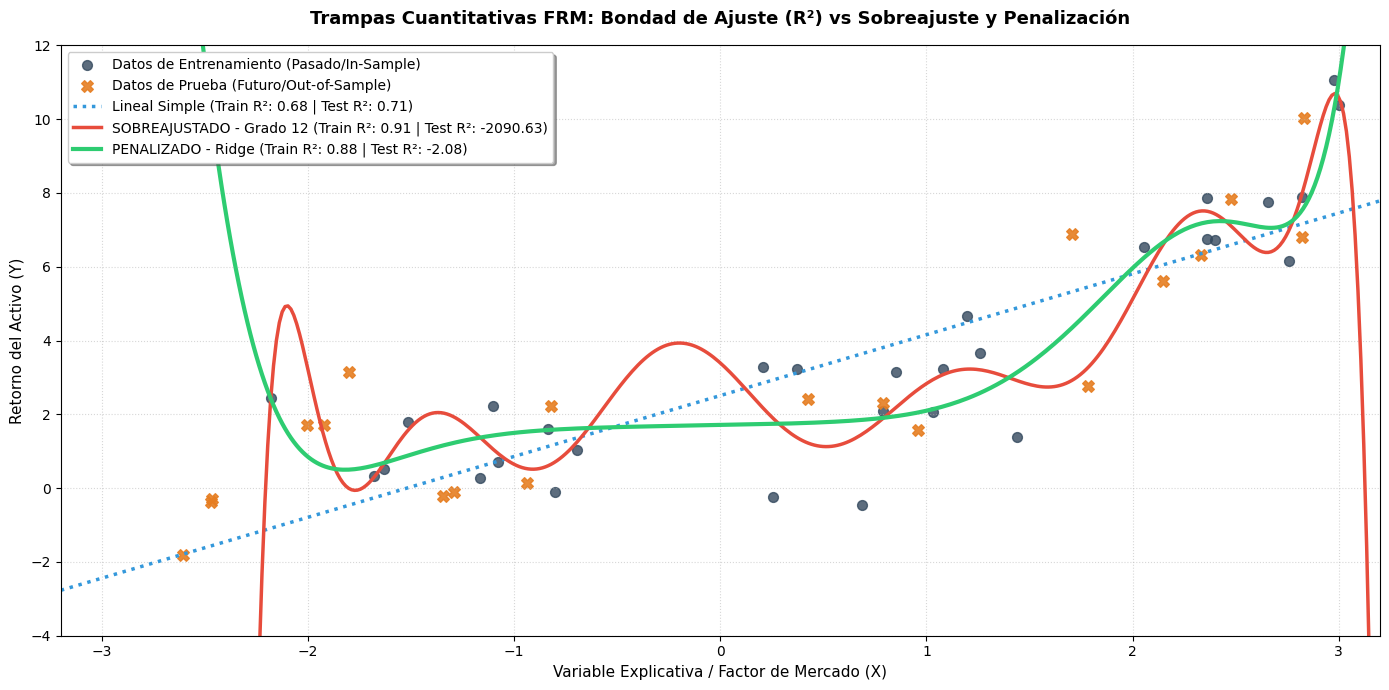

====================== DIAGNÓSTICO DE MODELOS FINANCIEROS ======================
1. Modelo Lineal Simple:   R² In-Sample = 0.6812  |  R² Out-of-Sample = 0.7051
2. Modelo SOBREAJUSTADO:   R² In-Sample = 0.9069  |  R² Out-of-Sample = -2090.6285  <-- ¡COLAPSO!
3. Modelo PENALIZADO:      R² In-Sample = 0.8827  |  R² Out-of-Sample = -2.0841  <-- ¡ROBUSTO!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# 1. GENERACIÓN DE DATOS FINANCIEROS (Sección de Entrenamiento vs Prueba)
np.random.seed(24)
N = 30

# Datos de Entrenamiento (El pasado que el analista usa para calibrar el modelo)
X_train = np.sort(np.random.uniform(-3, 3, N))
ruido_train = np.random.normal(0, 1.2, N)
Y_train = 0.5 * X_train**2 + 1.2 * X_train + 1.0 + ruido_train

# Datos de Prueba / Out-of-Sample (El futuro real del mercado para evaluar el modelo)
X_test = np.sort(np.random.uniform(-3, 3, 20))
ruido_test = np.random.normal(0, 1.2, 20)
Y_test = 0.5 * X_test**2 + 1.2 * X_test + 1.0 + ruido_test

# Reshape para compatibilidad con Scikit-Learn
X_train_df = X_train.reshape(-1, 1)
X_test_df = X_test.reshape(-1, 1)

# Eje X continuo para poder graficar las curvas suaves de los modelos
X_plot = np.linspace(-3.5, 3.5, 500).reshape(-1, 1)

# =============================================================================
# 2. CALIBRACIÓN DE LOS TRES MODELOS CUANTITATIVOS
# =============================================================================

# Modelo 1: Regresión Lineal Simple (Grado 1)
modelo_simple = LinearRegression()
modelo_simple.fit(X_train_df, Y_train)
Y_plot_simple = modelo_simple.predict(X_plot)

# Modelo 2: Modelo Sobreajustado (Overfitting - Polinomio de Grado 12)
# Agrega múltiples dimensiones artificiales para forzar al modelo a tocar cada punto de ruido
modelo_overfit = make_pipeline(PolynomialFeatures(degree=12), LinearRegression())
modelo_overfit.fit(X_train_df, Y_train)
Y_plot_overfit = modelo_overfit.predict(X_plot)

# Modelo 3: Modelo Penalizado (Ridge Regression - Grado 12 con penalización L2)
# El parámetro 'alpha' penaliza los coeficientes grandes, suavizando la curva drásticamente
modelo_penalizado = make_pipeline(PolynomialFeatures(degree=12), Ridge(alpha=50.0))
modelo_penalizado.fit(X_train_df, Y_train)
Y_plot_penalized = modelo_penalizado.predict(X_plot)

# =============================================================================
# 3. CÁLCULO DE LA BONDAD DE AJUSTE (R²) EN ENTRENAMIENTO VS PRUEBA
# =============================================================================
r2_simple_train = r2_score(Y_train, modelo_simple.predict(X_train_df))
r2_simple_test  = r2_score(Y_test, modelo_simple.predict(X_test_df))

r2_overfit_train = r2_score(Y_train, modelo_overfit.predict(X_train_df))
r2_overfit_test  = r2_score(Y_test, modelo_overfit.predict(X_test_df))

r2_penal_train = r2_score(Y_train, modelo_penalizado.predict(X_train_df))
r2_penal_test  = r2_score(Y_test, modelo_penalizado.predict(X_test_df))

# =============================================================================
# 4. VISUALIZACIÓN DEL DILEMA DEL QUANT (SESGO VS VARIANZA)
# =============================================================================
plt.figure(figsize=(14, 7))

# Graficar los datos históricos y los datos futuros
plt.scatter(X_train, Y_train, color='#34495e', s=50, label='Datos de Entrenamiento (Pasado/In-Sample)', alpha=0.8)
plt.scatter(X_test, Y_test, color='#e67e22', marker='X', s=70, label='Datos de Prueba (Futuro/Out-of-Sample)', alpha=0.9)

# Graficar las curvas de predicción de cada estrategia
plt.plot(X_plot, Y_plot_simple, color='#3498db', linewidth=2.5, linestyle=':',
         label=f'Lineal Simple (Train R²: {r2_simple_train:.2f} | Test R²: {r2_simple_test:.2f})')

plt.plot(X_plot, Y_plot_overfit, color='#e74c3c', linewidth=2.5,
         label=f'SOBREAJUSTADO - Grado 12 (Train R²: {r2_overfit_train:.2f} | Test R²: {r2_overfit_test:.2f})')

plt.plot(X_plot, Y_plot_penalized, color='#2ecc71', linewidth=3,
         label=f'PENALIZADO - Ridge (Train R²: {r2_penal_train:.2f} | Test R²: {r2_penal_test:.2f})')

# Formato de la gráfica para reporte académico
plt.title('Trampas Cuantitativas FRM: Bondad de Ajuste (R²) vs Sobreajuste y Penalización', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Variable Explicativa / Factor de Mercado (X)', fontsize=11)
plt.ylabel('Retorno del Activo (Y)', fontsize=11)
plt.xlim(-3.2, 3.2)
plt.ylim(-4, 12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# =============================================================================
# 5. REPORTE ACADÉMICO PARA EL EXAMEN
# =============================================================================
print("====================== DIAGNÓSTICO DE MODELOS FINANCIEROS ======================")
print(f"1. Modelo Lineal Simple:   R² In-Sample = {r2_simple_train:.4f}  |  R² Out-of-Sample = {r2_simple_test:.4f}")
print(f"2. Modelo SOBREAJUSTADO:   R² In-Sample = {r2_overfit_train:.4f}  |  R² Out-of-Sample = {r2_overfit_test:.4f}  <-- ¡COLAPSO!")
print(f"3. Modelo PENALIZADO:      R² In-Sample = {r2_penal_train:.4f}  |  R² Out-of-Sample = {r2_penal_test:.4f}  <-- ¡ROBUSTO!")
print("================================================================================")
